import pandas as pd
import numpy as np
import random
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch.nn as nn
import torch
from typing import Union
import warnings
from datetime import datetime
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from neuralforecast.core import NeuralForecast
from neuralforecast.models import PatchTST, TFT, DilatedRNN, VanillaTransformer, iTransformer
from neuralforecast.losses.pytorch import MAE, MSE
import argparse
import sys
import os
from Data.Data_Generator_ILI_HHS_TimeSplit import prepare_ILI_data
from Utils import drop_last_n_samples, splitter
import contextlib
import io
import pytorch_lightning as pl
import logging
import warnings
from pathlib import Path
import os
os.environ["NIXTLA_ID_AS_COL"] = "True"


In [13]:
hospital_df = pd.read_pickle("hospitalization_data.pkl")
# hospital_df['DATE'] = hospital_df['ds']
# hospital_df['ds'] = hospital_df.groupby('unique_id').cumcount().add(1)  # 1,2,3,…

hospital_df

,ds,unique_id,y
0,2022-02-12,Region 1,44.0
1,2022-02-19,Region 1,57.0
2,2022-02-26,Region 1,44.0
3,2022-03-05,Region 1,21.0
4,2022-03-12,Region 1,47.0
...,...,...,...
1675,2025-03-29,Region 9,888.0
1676,2025-04-05,Region 9,626.0
1677,2025-04-12,Region 9,551.0
1678,2025-04-19,Region 9,486.0


In [3]:
path_to_data = "Data/ILINet.csv"
test_size = 0.2
train_df, test_df, df, data, number_of_time_series, length_time_series, forecasting_horizon, number_of_samples_in_test = prepare_ILI_data(path_to_data, test_size)
data

,YEAR,WEEK,REGION,% WEIGHTED ILI,Indicator,DATE
0,2005,46,Region 1,0.905434,1,2005-11-14
1,2005,47,Region 1,1.012450,2,2005-11-21
2,2005,48,Region 1,0.835424,3,2005-11-28
3,2005,49,Region 1,1.093970,4,2005-12-05
4,2005,50,Region 1,0.995161,5,2005-12-12
...,...,...,...,...,...,...
9995,2024,50,Region 9,5.010590,996,2024-12-09
9996,2024,51,Region 9,6.326640,997,2024-12-16
9997,2024,52,Region 9,8.672490,998,2024-12-23
9998,2025,1,Region 9,8.003280,999,2025-01-06


  0%|          | 0/1 [00:00<?, ?it/s][rank: 0] Seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MSE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 403 K  | train
-----------------------------------------------------------
403 K     Trainable params
3         Non-trainable params
403 K     Total params
1.614     Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=150` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MSE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 403 K  | train
-----------------------------------------------------------
403 K     Trainable params
3         Non-trainable params
403 K     Total params
1.614     Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=150` reached.


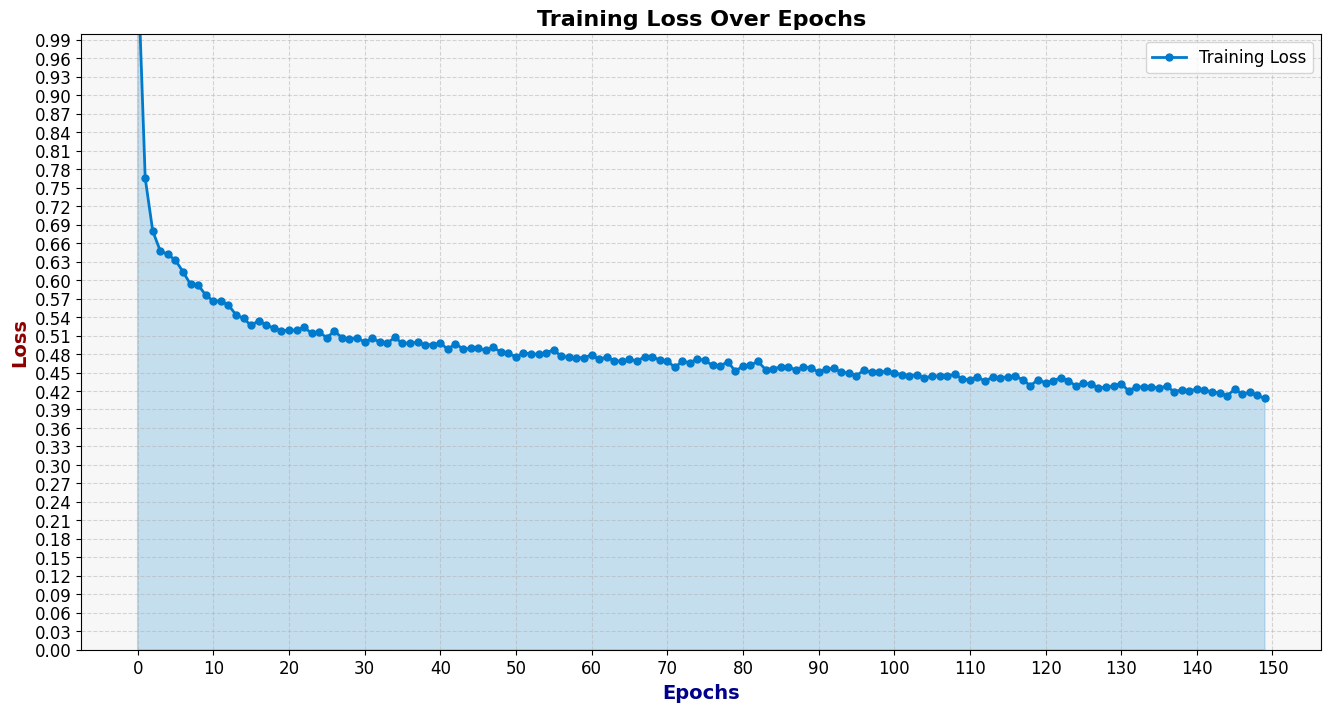

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Starting evaluation ....



  0%|          | 0/200 [00:00<?, ?it/s]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

`Trainer.fit` stopped: `max_steps=150` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=150` reached.


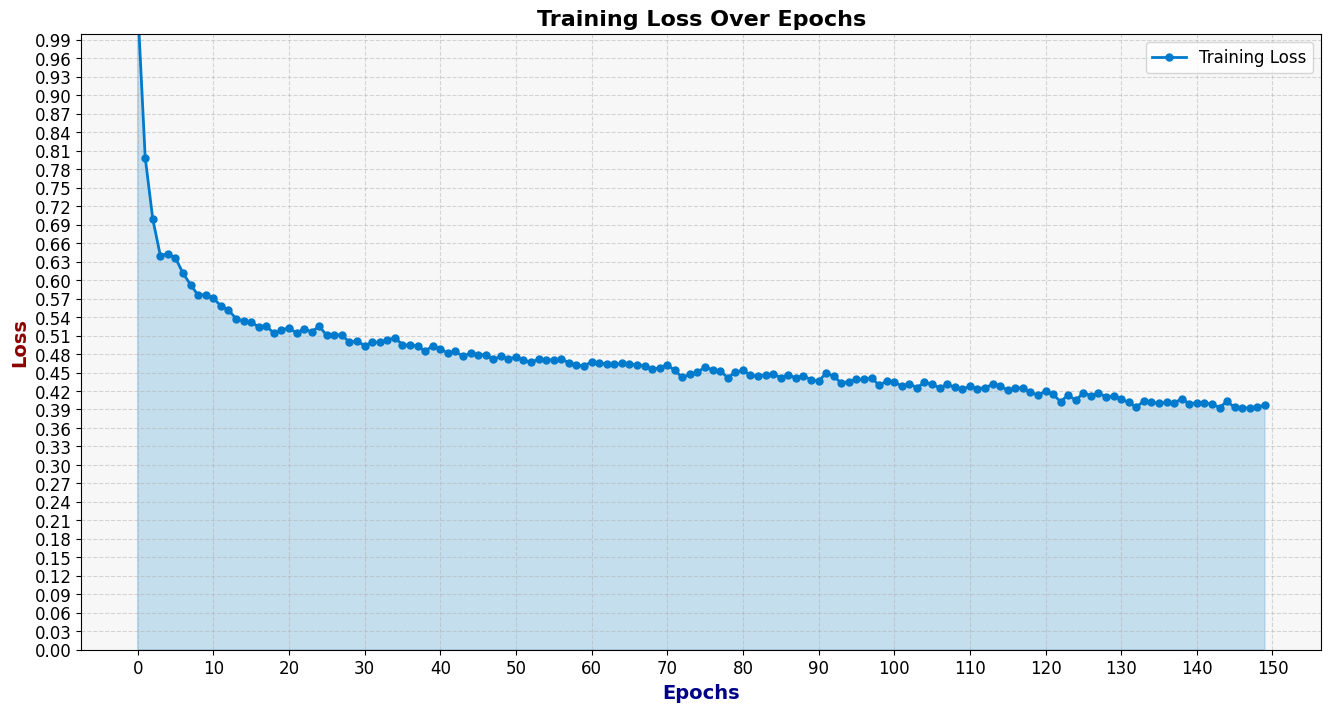

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Starting evaluation ....



  0%|          | 0/200 [00:00<?, ?it/s]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]


  0%|          | 1/200 [00:00<01:15,  2.65it/s]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

`Trainer.fit` stopped: `max_steps=150` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=150` reached.


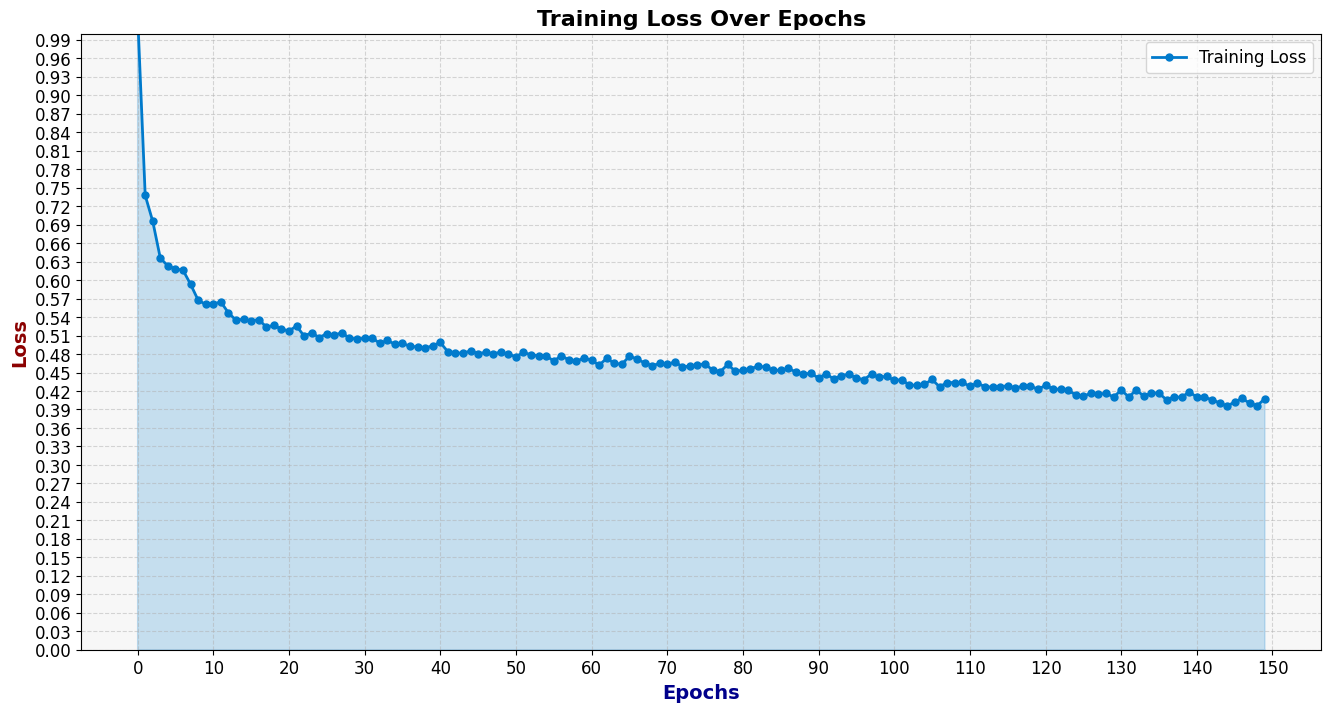

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Starting evaluation ....



  0%|          | 0/200 [00:00<?, ?it/s]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]


  0%|          | 1/200 [00:00<00:20,  9.69it/s]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

`Trainer.fit` stopped: `max_steps=150` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=150` reached.


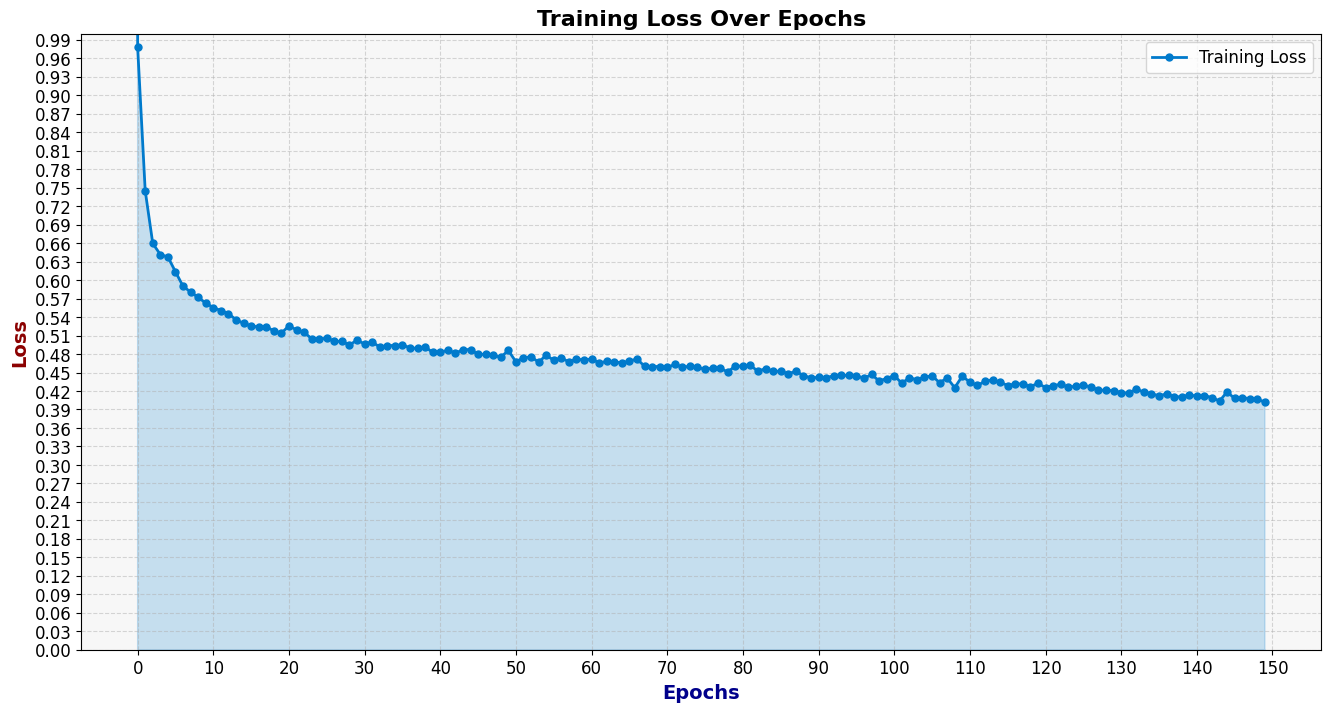

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Starting evaluation ....



  0%|          | 0/200 [00:00<?, ?it/s]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

`Trainer.fit` stopped: `max_steps=150` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=150` reached.


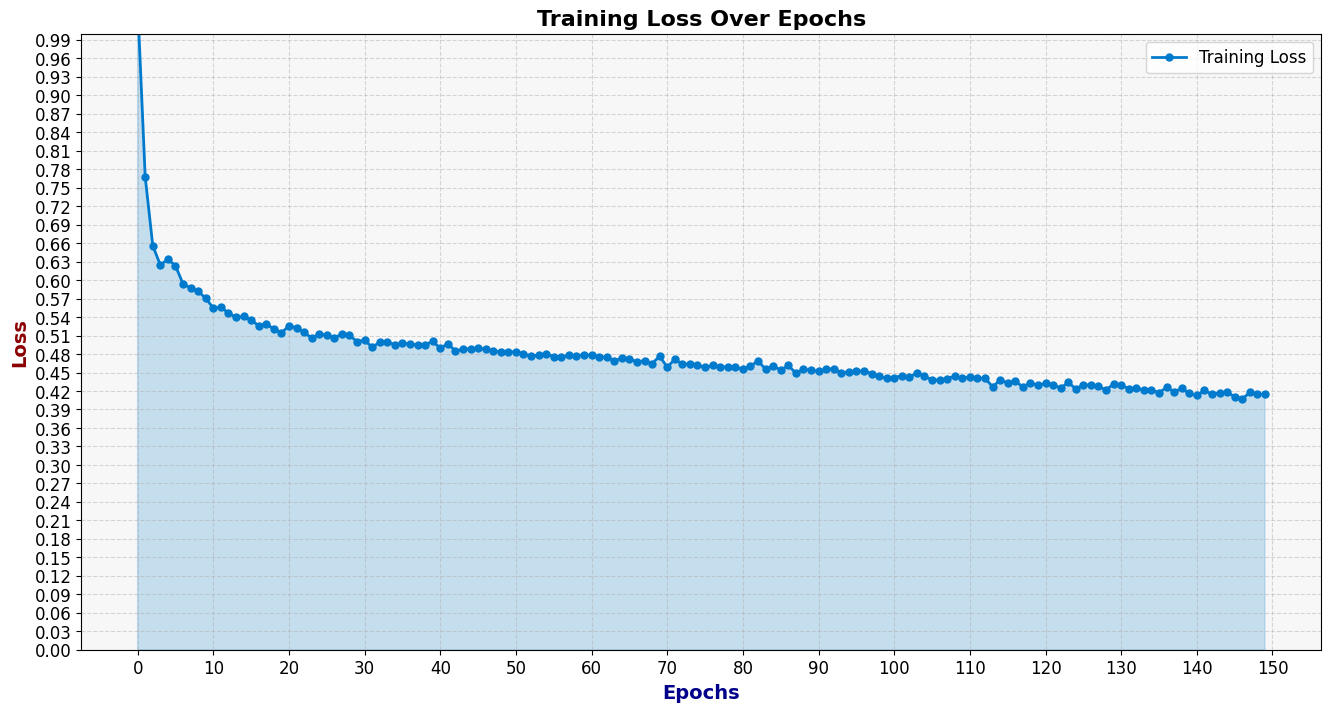

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Starting evaluation ....



  0%|          | 0/200 [00:00<?, ?it/s]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

`Trainer.fit` stopped: `max_steps=150` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=150` reached.


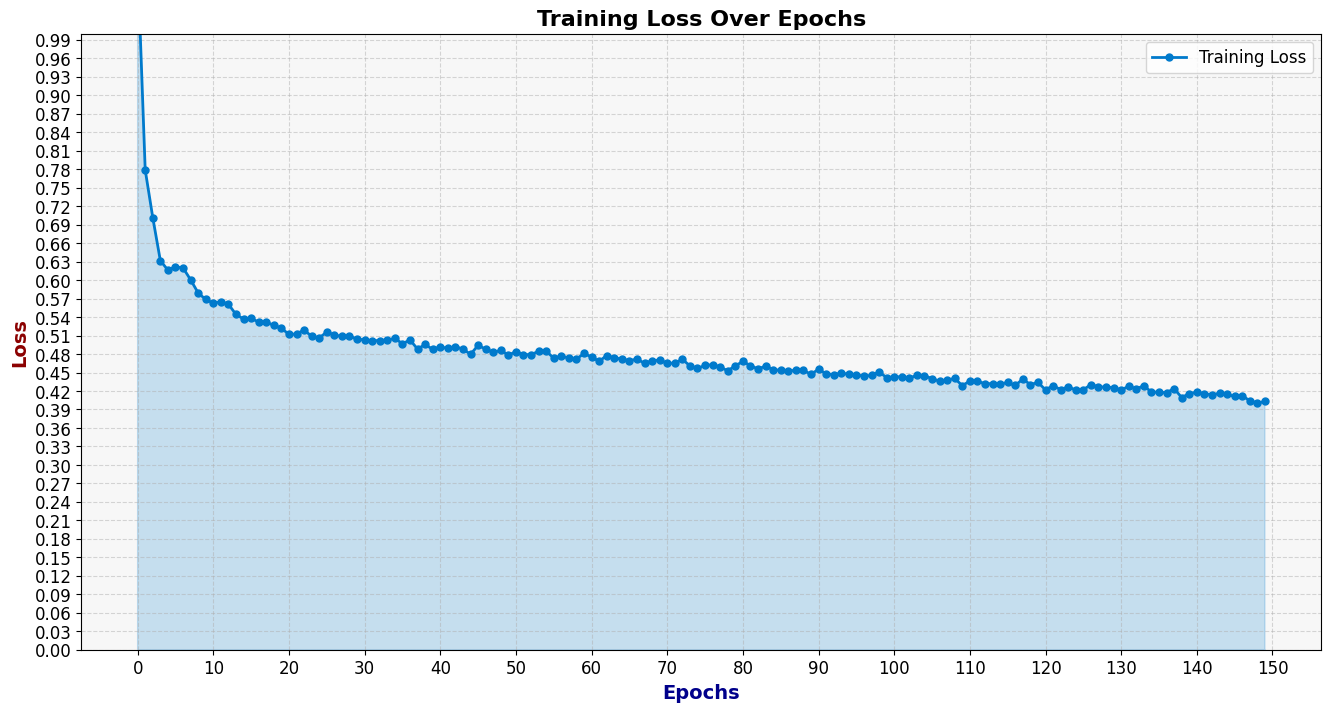

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Starting evaluation ....



  0%|          | 0/200 [00:00<?, ?it/s]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

Predicting: |          | 0/? [00:00<?, ?it/s]


100%|█████████▉| 199/200 [00:17<00:00, 10.71it/s]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

100%|██████████| 1/1 [00:39<00:00, 39.09s/it]

Evaluation ended.
    Dataset: ILI
    Model: PatchTST
    Target_series: % WEIGHTED ILI
    Feature: % WEIGHTED ILI
    Normalization: None

    Splitting_strategy: Time-based
    Validation: No
    Samples in one time series: 1000
    Samples in test part: 200
    Number of time series: 10
    Frequency: '1W'

    forecasting_horizon: 4
    Look back size: 52
    Step size: 1
    max_steps: 150
    loss: "MSE"
    learning_rate: 0.0005
    batch_size: 10
    scaler_type: None
    seed_neuralforecast: 6

    training loss (MSE): 0.40306
    ***RESULTS h1***
    MSE:    0.12599
    MAE:    0.20603
    SMAPE:  8.27263
    NNSE:   0.94983
    R²:     0.94718

    ***RESULTS h2***
    MSE:    0.33170
    MAE:    0.33817
    SMAPE:  13.68829
    NNSE:   0.87790
    R²:     0.86091

    ***RESULTS h3***
    MSE:    0.50598
    MAE:    0.42863
    SMAPE:  17.97175
    NNSE:   0.82498
    R²:     0.78785

    ***RESULTS h4***
    MSE:    0.66810
    MAE:    0.50045
    SMAPE:  21.31045
    NN

In [4]:

for seed in [1,2,3,4,5,6]:
    
    model = "PatchTST"
    forecasting_horizon = 4
    look_back_size=52
    batch_size = number_of_time_series
    learning_rate=5e-4
    max_steps = 150
    path_to_model = f"{model}/{model}_TimeSplit.py"
    scaler_type = None
    step_size=1 
    window_retrain = 200
    
    path_to_results = f"{model}/TB_h4_lr_{learning_rate}_epoch_{max_steps}_lbs_{look_back_size}_window_retrain_{window_retrain}"
    if not os.path.exists(path_to_results):
        os.makedirs(path_to_results)
        
    all_preds = pd.DataFrame()
    for s, index_splitter_train_test_data in enumerate(tqdm(range(number_of_samples_in_test, 0, -window_retrain))):
        
        train_df, _ = splitter(df, 'unique_id', index_splitter_train_test_data)
        number_of_samples_in_train = len(train_df)/number_of_time_series

        # Model configuration
        models = [PatchTST (h=forecasting_horizon, 
                      input_size=look_back_size, 
                      max_steps=max_steps, 
                      learning_rate=learning_rate, 
                      loss=MSE(), random_seed=seed, 
                      scaler_type=scaler_type, 
                      batch_size=batch_size, 
                      step_size=step_size,
                      windows_batch_size=int(batch_size*(number_of_samples_in_train-forecasting_horizon-look_back_size+1))
                     )]
        nf = NeuralForecast(models=models, freq=1, local_scaler_type=scaler_type)
        
        
        nf.fit(hospital_df, verbose=True, val_size=0) #COVID19_df, TrafficL_df, M4_weekly_df
        nf.fit(train_df, verbose=True, val_size=0)
        

        # Extract training loss
        training_loss = getattr(nf.models[0], "train_trajectories", [])
        epochs = [epoch for epoch, loss in training_loss]
        loss_values = [loss for epoch, loss in training_loss]

        # Plot and save training loss
        plt.figure(figsize=(16, 8))
        plt.plot(epochs, loss_values, marker='o', linestyle='-', color='#007acc', linewidth=2, markersize=5, label='Training Loss')
        plt.xlabel("Epochs", fontsize=14, fontweight='bold', color='darkblue')
        plt.ylabel("Loss", fontsize=14, fontweight='bold', color='darkred')
        plt.title("Training Loss Over Epochs", fontsize=16, fontweight='bold', color='black')
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.gca().set_facecolor("#f7f7f7")
        plt.fill_between(epochs, loss_values, alpha=0.2, color='#007acc')
        plt.xticks(fontsize=12, color='black')
        plt.yticks(fontsize=12, color='black')
        ax = plt.gca()
        ax.set_ylim([0, 1])
        ax.yaxis.set_major_locator(ticker.MultipleLocator(0.03))
        ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
        plt.legend(fontsize=12, loc='upper right')
        plt.savefig(f"{path_to_results}/training_loss_plot_TB_h{forecasting_horizon}_s{seed}_{s}.png", dpi=300, bbox_inches='tight')
        plt.show()

        trainer = pl.Trainer(logger=False)
        logging.getLogger().setLevel(logging.ERROR)
        logging.getLogger("pytorch_lightning").setLevel(logging.CRITICAL)
        warnings.filterwarnings("ignore")

        def transform_df(df):
            first_ds_values = df.groupby("unique_id")["ds"].first().reset_index()
            first_ds_values.rename(columns={"ds": "first_ds"}, inplace=True)
            df_pivot = df.pivot(index='unique_id', columns='ds', values=model)
            df_pivot.columns = ['y_hat_1', 'y_hat_2', 'y_hat_3', 'y_hat_4']
            df_pivot = df_pivot.reset_index()
            df_pivot = df_pivot.merge(first_ds_values, on="unique_id")
            column_order = ["first_ds", "unique_id", 'y_hat_1', 'y_hat_2', 'y_hat_3', 'y_hat_4']
            df_pivot = df_pivot[column_order]
            return df_pivot

        print("Starting evaluation ....")
        for idx, i in enumerate(tqdm(range(index_splitter_train_test_data, index_splitter_train_test_data-window_retrain, -1))):
            _, data_batch_part = splitter(df, 'unique_id', i + look_back_size)
            data_batch_part = drop_last_n_samples(data_batch_part, 'unique_id', i)
            preds = nf.predict(data_batch_part)
            preds = preds.reset_index(drop=True)
            transformed_df = transform_df(preds)
            all_preds = pd.concat([all_preds, transformed_df], ignore_index=True)
        print("Evaluation ended.")

        def shift_up_by_group(df, group_col, columns_to_shift, shift_by, fill_value=0):
            shifted_groups = []
            unique_groups = df[group_col].unique()
            for grp_value in unique_groups:
                group_data = df[df[group_col] == grp_value].copy()
                group_data[columns_to_shift] = group_data[columns_to_shift].shift(shift_by)
                shifted_groups.append(group_data)
            df_shifted = pd.concat(shifted_groups, ignore_index=True)
            return df_shifted[columns_to_shift]


    all_preds = all_preds.sort_values(by=['unique_id', 'first_ds'], ascending=[True, True])
    test_df = test_df.sort_values(by=['unique_id', 'ds'], ascending=[True, True])
    results_df = all_preds.copy()
    results_df = results_df.reset_index(drop=True)
    test_df    = test_df.reset_index(drop=True)
    results_df['y_actual_1'] = test_df['y'].values
    results_df['y_actual_2'] = shift_up_by_group(test_df, group_col='unique_id', columns_to_shift=['y'],shift_by=-1, fill_value=0)
    results_df['y_actual_3'] = shift_up_by_group(test_df, group_col='unique_id', columns_to_shift=['y'],shift_by=-2, fill_value=0)
    results_df['y_actual_4'] = shift_up_by_group(test_df, group_col='unique_id', columns_to_shift=['y'],shift_by=-3, fill_value=0)


    def results_calculator(df, group_col, traget_y, predicted_y, shift_by, number_of_time_series, number_of_samples_in_test):
        filtered_df = df[['first_ds', 'unique_id', traget_y, predicted_y]]
        shifted_groups = []
        unique_groups = df[group_col].unique()
        for grp_value in unique_groups:
            group_data = df[df[group_col] == grp_value].copy()
            group_data.drop(group_data.tail(shift_by).index, inplace=True)
            shifted_groups.append(group_data)
        df_shifted = pd.concat(shifted_groups, ignore_index=True)

        Y_ACTUAL = df_shifted[traget_y].values.reshape(number_of_time_series, number_of_samples_in_test-shift_by)
        Y_HAT = df_shifted[predicted_y].values.reshape(number_of_time_series, number_of_samples_in_test-shift_by)

        mae = np.mean(np.abs(Y_ACTUAL - Y_HAT))
        mse = np.mean(np.square(Y_ACTUAL - Y_HAT))
        nnse = 1 / (2 - (1 - np.sum(np.square(Y_ACTUAL - Y_HAT)) / np.sum(np.square(Y_ACTUAL - np.mean(Y_ACTUAL)))))
        r2 = 1 - (np.sum(np.square(Y_ACTUAL - Y_HAT)) / np.sum(np.square(Y_ACTUAL - np.mean(Y_ACTUAL))))
        smape = 100 * np.mean(2 * np.abs(Y_HAT - Y_ACTUAL) / (np.abs(Y_ACTUAL) + np.abs(Y_HAT) + 1e-8))

        return mae, mse, nnse, smape, r2


    mae_1, mse_1, nnse_1, smape_1, r2_1 = results_calculator(results_df, 'unique_id', 'y_actual_1', 'y_hat_1', 0, number_of_time_series, number_of_samples_in_test)
    mae_2, mse_2, nnse_2, smape_2, r2_2 = results_calculator(results_df, 'unique_id', 'y_actual_2', 'y_hat_2', 1, number_of_time_series, number_of_samples_in_test)
    mae_3, mse_3, nnse_3, smape_3, r2_3 = results_calculator(results_df, 'unique_id', 'y_actual_3', 'y_hat_3', 2, number_of_time_series, number_of_samples_in_test)
    mae_4, mse_4, nnse_4, smape_4, r2_4 = results_calculator(results_df, 'unique_id', 'y_actual_4', 'y_hat_4', 3, number_of_time_series, number_of_samples_in_test)

    avg_mse = (mse_1+mse_2+mse_3+mse_4)/4

    # Save results
    config_text = f"""\
    Dataset: ILI
    Model: {model}
    Target_series: % WEIGHTED ILI
    Feature: % WEIGHTED ILI
    Normalization: None

    Splitting_strategy: Time-based
    Validation: No
    Samples in one time series: {length_time_series}
    Samples in test part: {number_of_samples_in_test}
    Number of time series: {number_of_time_series}
    Frequency: '1W'

    forecasting_horizon: {forecasting_horizon}
    Look back size: {look_back_size}
    Step size: {step_size}
    max_steps: {max_steps}
    loss: "MSE"
    learning_rate: {learning_rate}
    batch_size: {batch_size}
    scaler_type: {scaler_type}
    seed_neuralforecast: {seed}

    training loss (MSE): {loss_values[-1]:.5f}
    ***RESULTS h1***
    MSE:    {mse_1:.5f}
    MAE:    {mae_1:.5f}
    SMAPE:  {smape_1:.5f}
    NNSE:   {nnse_1:.5f}
    R²:     {r2_1:.5f}

    ***RESULTS h2***
    MSE:    {mse_2:.5f}
    MAE:    {mae_2:.5f}
    SMAPE:  {smape_2:.5f}
    NNSE:   {nnse_2:.5f}
    R²:     {r2_2:.5f}

    ***RESULTS h3***
    MSE:    {mse_3:.5f}
    MAE:    {mae_3:.5f}
    SMAPE:  {smape_3:.5f}
    NNSE:   {nnse_3:.5f}
    R²:     {r2_3:.5f}

    ***RESULTS h4***
    MSE:    {mse_4:.5f}
    MAE:    {mae_4:.5f}
    SMAPE:  {smape_4:.5f}
    NNSE:   {nnse_4:.5f}
    R²:     {r2_4:.5f}

    ***Average MSE***
    avg_mse: {avg_mse}
    """

    with open(f"{path_to_results}/Results_TB_h{forecasting_horizon}_s{seed}.txt", "w") as file:
        file.write(config_text)

    print(config_text)


In [5]:
import os
import glob
import statistics
import re

def parse_metrics_from_file(filepath):
    """
    Parse the desired metrics from a single results file.
    Returns a dictionary with the following structure:
    {
      "training_loss": float,
      "avg_mse": float,
      "h1": {"MSE": float, "MAE": float, "SMAPE": float, "NNSE": float, "R2": float},
      "h2": {...},
      "h3": {...},
      "h4": {...}
    }
    If something is not found, returns None for that field.
    """

    # Initialize the dict with None (or any default) for each metric
    metrics_dict = {
        "training_loss": None,
        "avg_mse": None,
        "h1": {"MSE": None, "MAE": None, "SMAPE": None, "NNSE": None, "R2": None},
        "h2": {"MSE": None, "MAE": None, "SMAPE": None, "NNSE": None, "R2": None},
        "h3": {"MSE": None, "MAE": None, "SMAPE": None, "NNSE": None, "R2": None},
        "h4": {"MSE": None, "MAE": None, "SMAPE": None, "NNSE": None, "R2": None},
    }

    # Regex patterns to extract numbers (floats). 
    # We'll look for lines like: "training loss (MSE): 0.39443" or "MSE:    0.15226"
    # Adjust the patterns if your file format changes.
    pattern_training_loss = re.compile(r"training loss.*:\s*([0-9.]+)")
    pattern_avg_mse = re.compile(r"avg_mse:\s*([0-9.]+)")

    # For lines like "***RESULTS h1***" we capture h1
    # For lines like "MSE:\s*([0-9.]+)"
    pattern_horizon = re.compile(r"\*\*\*RESULTS\s+(h[0-9]+)\*\*\*")
    pattern_key_value = re.compile(r"(MSE|MAE|SMAPE|NNSE|R²?):\s*([0-9.]+)")

    current_horizon = None

    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()

            # 1) Training Loss
            train_match = pattern_training_loss.search(line)
            if train_match:
                metrics_dict["training_loss"] = float(train_match.group(1))
                continue

            # 2) Average MSE
            avg_mse_match = pattern_avg_mse.search(line)
            if avg_mse_match:
                metrics_dict["avg_mse"] = float(avg_mse_match.group(1))
                continue

            # 3) Detect horizon header (e.g. ***RESULTS h1***)
            horizon_match = pattern_horizon.search(line)
            if horizon_match:
                current_horizon = horizon_match.group(1)  # e.g. 'h1', 'h2', etc.
                continue

            # 4) Inside horizon block, parse lines like "MSE:    0.15226"
            if current_horizon is not None:
                kv_match = pattern_key_value.search(line)
                if kv_match:
                    metric_name = kv_match.group(1)  # e.g. 'MSE'
                    metric_value = float(kv_match.group(2))

                    # Correct potential mismatch 'R²' vs 'R2' dictionary key
                    if metric_name.startswith('R'):
                        metric_name = "R2"

                    metrics_dict[current_horizon][metric_name] = metric_value

    return metrics_dict


def main(results_folder="path/to/results_folder"):
    """
    1. Collect all .txt files (or any extension) from the specified results_folder
    2. Parse metrics for each file
    3. Aggregate all metrics (mean, std)
    """

    # A structure to accumulate metric values across all files
    # We'll store lists, then compute mean and std afterwards
    all_metrics = {
        "training_loss": [],
        "avg_mse": [],
        "h1": {"MSE": [], "MAE": [], "SMAPE": [], "NNSE": [], "R2": []},
        "h2": {"MSE": [], "MAE": [], "SMAPE": [], "NNSE": [], "R2": []},
        "h3": {"MSE": [], "MAE": [], "SMAPE": [], "NNSE": [], "R2": []},
        "h4": {"MSE": [], "MAE": [], "SMAPE": [], "NNSE": [], "R2": []},
    }

    # Modify the glob pattern as needed (e.g. *.txt, *.log, etc.)
    file_list = glob.glob(os.path.join(results_folder, "*.txt"))

    for file_path in file_list:
        parsed = parse_metrics_from_file(file_path)

        # Append each metric if found
        if parsed["training_loss"] is not None:
            all_metrics["training_loss"].append(parsed["training_loss"])
        if parsed["avg_mse"] is not None:
            all_metrics["avg_mse"].append(parsed["avg_mse"])

        for horizon in ["h1", "h2", "h3", "h4"]:
            for mkey in ["MSE", "MAE", "SMAPE", "NNSE", "R2"]:
                val = parsed[horizon].get(mkey, None)
                if val is not None:
                    all_metrics[horizon][mkey].append(val)

    # Helper to compute mean and sample std
    def mean_std(values):
        if len(values) == 0:
            return (None, None)
        return (statistics.mean(values), statistics.stdev(values))

    # Print aggregated results
    print("===== AGGREGATED RESULTS ACROSS ALL FILES =====")
    # training_loss
    mean_val, std_val = mean_std(all_metrics["training_loss"])
    print(f"Training Loss (MSE): mean={mean_val:.3f}, std={std_val:.3f}")

    # avg_mse
    mean_val, std_val = mean_std(all_metrics["avg_mse"])
    print(f"Average MSE:         mean={mean_val:.3f}, std={std_val:.3f}")

    # For each horizon and each metric
    for horizon in ["h1", "h2", "h3", "h4"]:
        print(f"\n--- {horizon.upper()} ---")
        for metric_name in ["MSE", "MAE", "SMAPE", "NNSE", "R2"]:
            mean_val, std_val = mean_std(all_metrics[horizon][metric_name])
            print(f"{metric_name}: mean={mean_val:.3f}, std={std_val:.3f}")



path_to_results = f"{model}/TB_h4_lr_{learning_rate}_epoch_{max_steps}_lbs_{look_back_size}_window_retrain_{window_retrain}"
main(results_folder=path_to_results)




===== AGGREGATED RESULTS ACROSS ALL FILES =====
Training Loss (MSE): mean=0.405, std=0.006
Average MSE:         mean=0.412, std=0.008

--- H1 ---
MSE: mean=0.124, std=0.005
MAE: mean=0.205, std=0.002
SMAPE: mean=8.268, std=0.063
NNSE: mean=0.950, std=0.002
R2: mean=0.948, std=0.002

--- H2 ---
MSE: mean=0.331, std=0.007
MAE: mean=0.337, std=0.002
SMAPE: mean=13.624, std=0.122
NNSE: mean=0.878, std=0.002
R2: mean=0.861, std=0.003

--- H3 ---
MSE: mean=0.515, std=0.013
MAE: mean=0.431, std=0.004
SMAPE: mean=17.914, std=0.225
NNSE: mean=0.822, std=0.004
R2: mean=0.784, std=0.005

--- H4 ---
MSE: mean=0.678, std=0.017
MAE: mean=0.506, std=0.005
SMAPE: mean=21.403, std=0.354
NNSE: mean=0.779, std=0.004
R2: mean=0.716, std=0.007


### PatchTST pretrained on Hospitalization

===== AGGREGATED RESULTS ACROSS ALL FILES =====

Average MSE:         mean=0.412, std=0.008

--- H1 ---
MSE: mean=0.124, std=0.005
MAE: mean=0.205, std=0.002
SMAPE: mean=8.268, std=0.063
NNSE: mean=0.950, std=0.002
R2: mean=0.948, std=0.002

--- H2 ---
MSE: mean=0.331, std=0.007
MAE: mean=0.337, std=0.002
SMAPE: mean=13.624, std=0.122
NNSE: mean=0.878, std=0.002
R2: mean=0.861, std=0.003

--- H3 ---
MSE: mean=0.515, std=0.013
MAE: mean=0.431, std=0.004
SMAPE: mean=17.914, std=0.225
NNSE: mean=0.822, std=0.004
R2: mean=0.784, std=0.005

--- H4 ---
MSE: mean=0.678, std=0.017
MAE: mean=0.506, std=0.005
SMAPE: mean=21.403, std=0.354
NNSE: mean=0.779, std=0.004
R2: mean=0.716, std=0.007

  0%|          | 0/1 [00:00<?, ?it/s][rank: 0] Seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=75` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=75` reached.


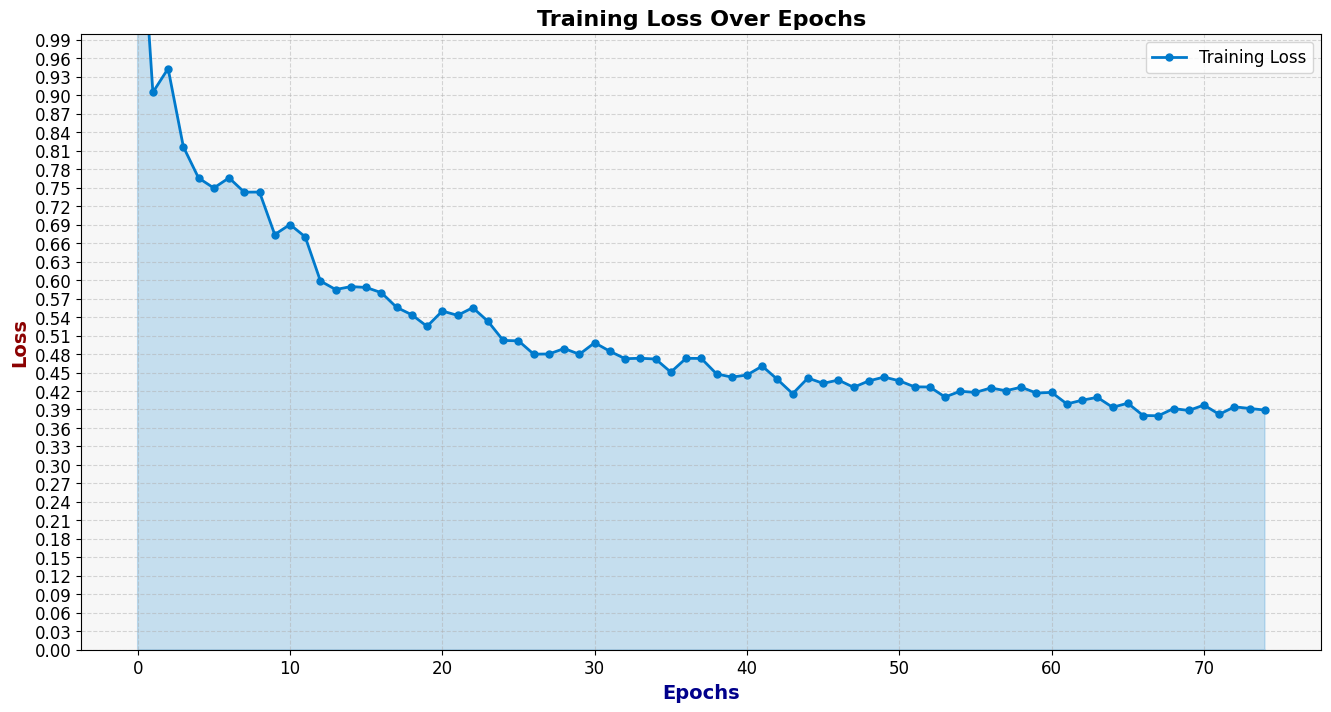

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Starting evaluation ....



  0%|          | 0/200 [00:00<?, ?it/s]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

`Trainer.fit` stopped: `max_steps=75` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=75` reached.


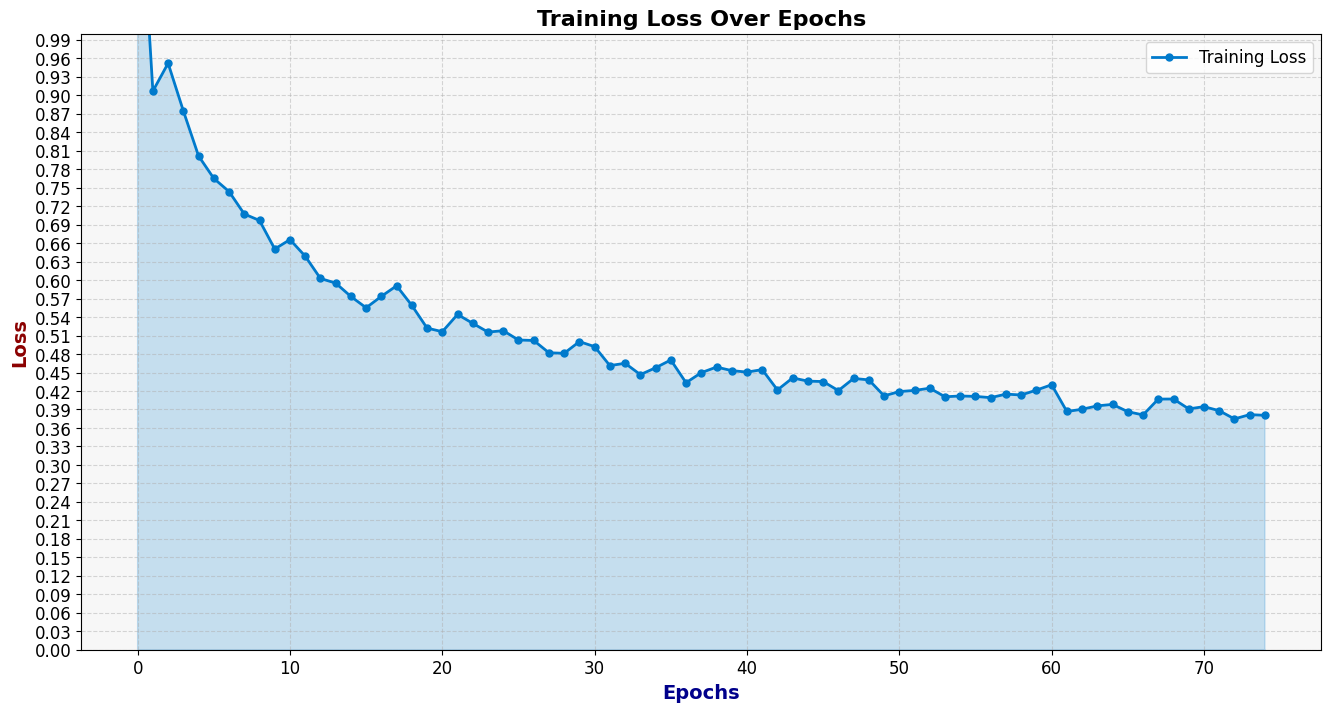

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Starting evaluation ....



  0%|          | 0/200 [00:00<?, ?it/s]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]


  0%|          | 1/200 [00:00<00:22,  8.90it/s]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

`Trainer.fit` stopped: `max_steps=75` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=75` reached.


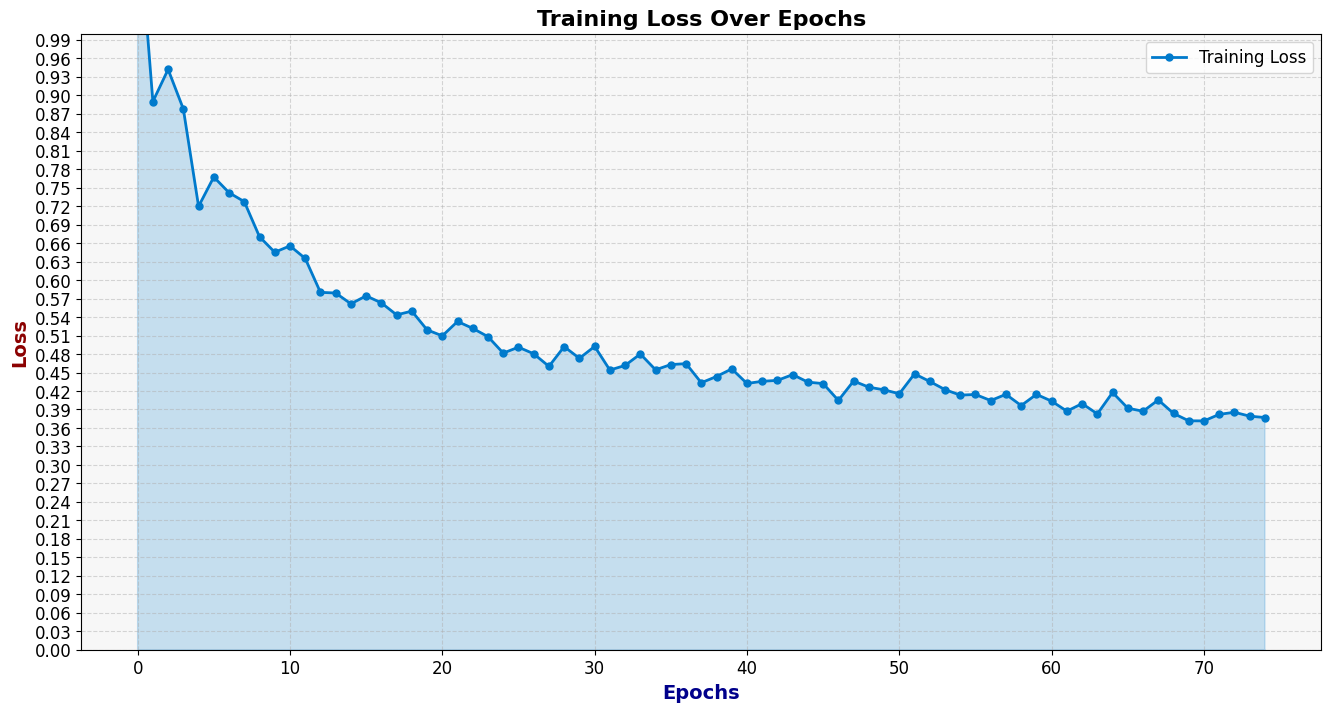

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Starting evaluation ....



  0%|          | 0/200 [00:00<?, ?it/s]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

`Trainer.fit` stopped: `max_steps=75` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=75` reached.


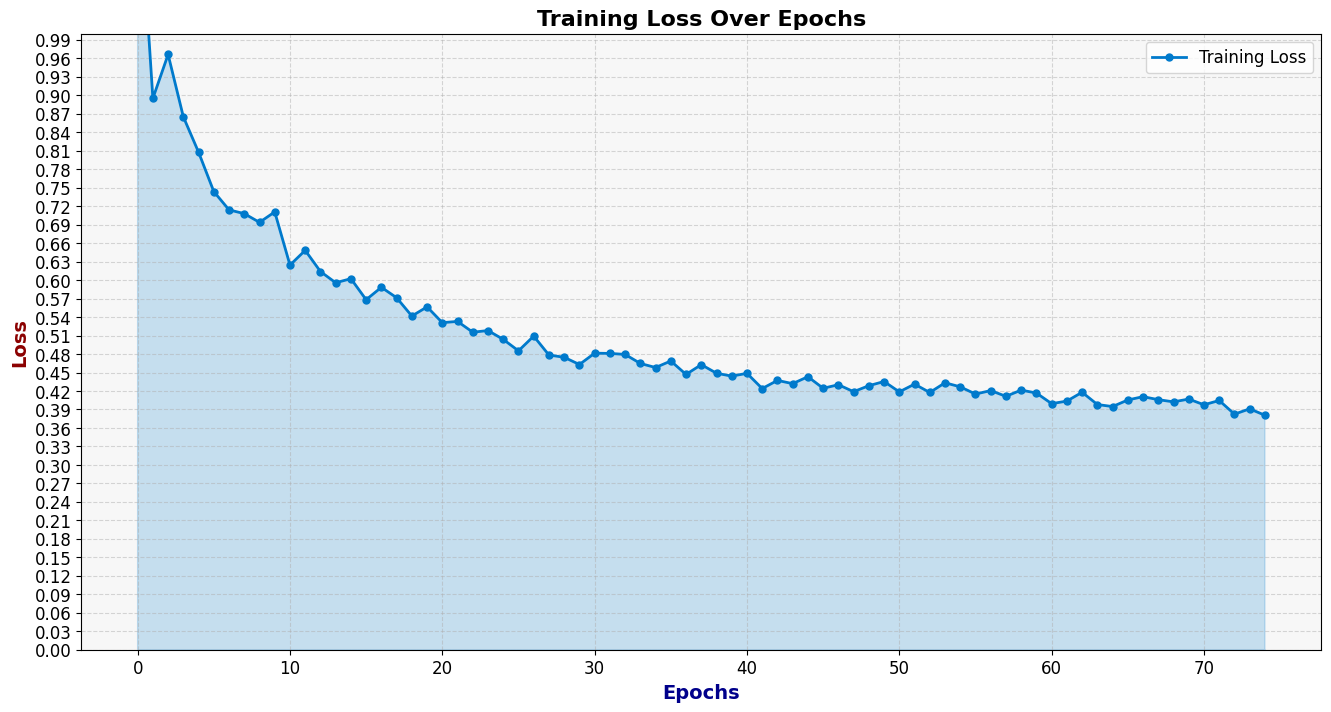

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Starting evaluation ....



  0%|          | 0/200 [00:00<?, ?it/s]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

`Trainer.fit` stopped: `max_steps=75` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=75` reached.


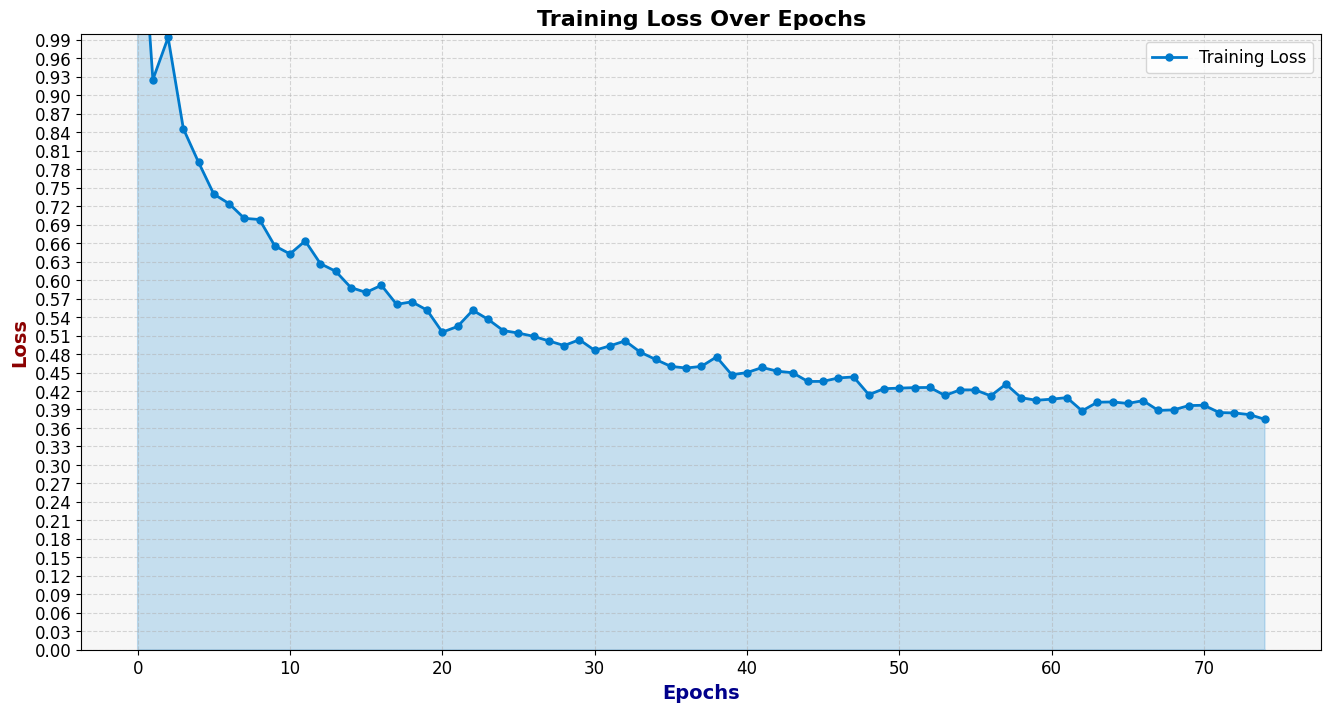

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Starting evaluation ....



  0%|          | 0/200 [00:00<?, ?it/s]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]


  0%|          | 1/200 [00:00<00:21,  9.11it/s]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

`Trainer.fit` stopped: `max_steps=75` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=75` reached.


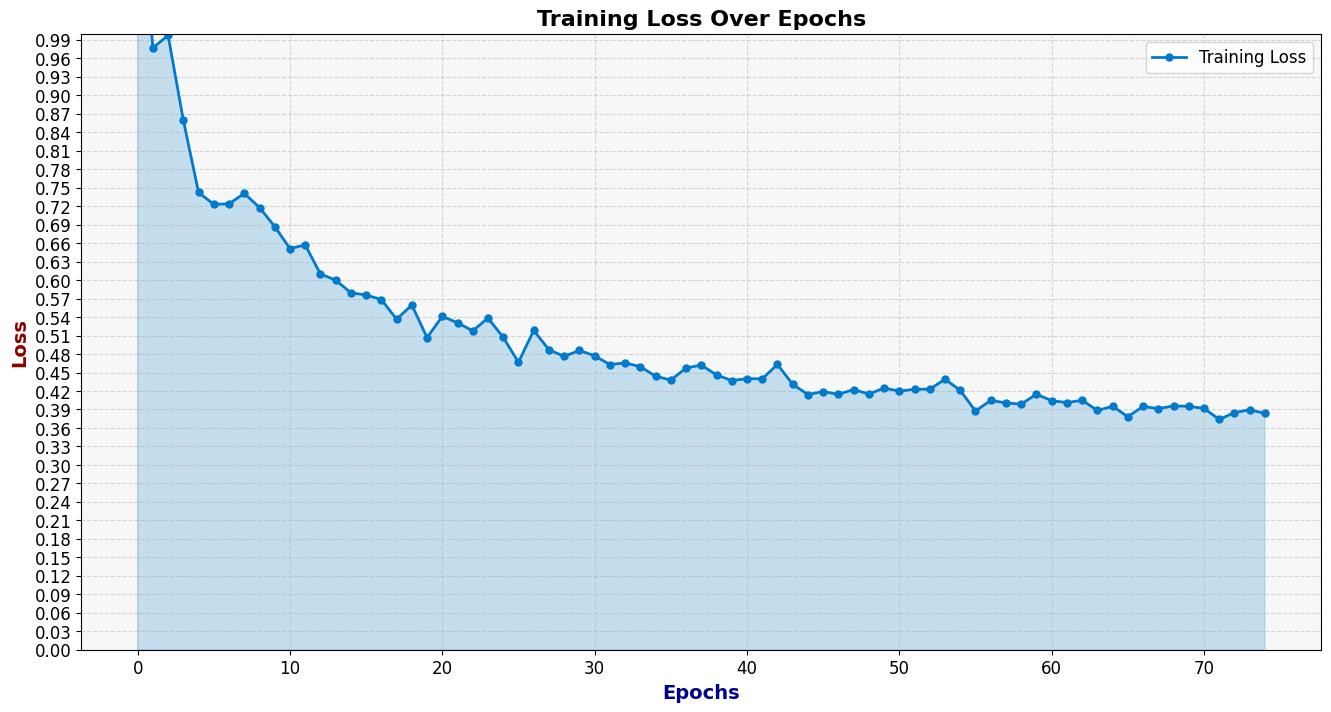

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Starting evaluation ....



  0%|          | 0/200 [00:00<?, ?it/s]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]


  0%|          | 1/200 [00:00<00:24,  8.16it/s]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]


100%|██████████| 1/1 [01:55<00:00, 115.84s/it]


Evaluation ended.
    Dataset: ILI
    Model: iTransformer
    Target_series: % WEIGHTED ILI
    Feature: % WEIGHTED ILI
    Normalization: None

    Splitting_strategy: Time-based
    Validation: No
    Samples in one time series: 1000
    Samples in test part: 200
    Number of time series: 10
    Frequency: '1W'

    forecasting_horizon: 4
    Look back size: 52
    Step size: 1
    max_steps: 75
    loss: "MSE"
    learning_rate: 0.0001
    batch_size: 10
    scaler_type: None
    seed_neuralforecast: 6

    training loss (MSE): 0.38369
    ***RESULTS h1***
    MSE:    0.13883
    MAE:    0.22840
    SMAPE:  9.94362
    NNSE:   0.94500
    R²:     0.94180

    ***RESULTS h2***
    MSE:    0.33511
    MAE:    0.35072
    SMAPE:  15.06418
    NNSE:   0.87680
    R²:     0.85948

    ***RESULTS h3***
    MSE:    0.51608
    MAE:    0.45078
    SMAPE:  20.02625
    NNSE:   0.82210
    R²:     0.78361

    ***RESULTS h4***
    MSE:    0.69273
    MAE:    0.53411
    SMAPE:  24.03070
   

In [11]:

for seed in [1,2,3,4,5,6]:
    
    model = "iTransformer"
    forecasting_horizon = 4
    look_back_size=52
    batch_size = number_of_time_series
    learning_rate=1e-4
    max_steps = 75
    path_to_model = f"{model}/{model}_TimeSplit.py"
    scaler_type = None
    step_size=1 
    window_retrain = 200
    
    path_to_results = f"{model}/TB_h4_lr_{learning_rate}_epoch_{max_steps}_lbs_{look_back_size}_window_retrain_{window_retrain}"
    if not os.path.exists(path_to_results):
        os.makedirs(path_to_results)
        
    all_preds = pd.DataFrame()
    for s, index_splitter_train_test_data in enumerate(tqdm(range(number_of_samples_in_test, 0, -window_retrain))):
        
        train_df, _ = splitter(df, 'unique_id', index_splitter_train_test_data)
        number_of_samples_in_train = len(train_df)/number_of_time_series

        # Model configuration
        models = [iTransformer (h=forecasting_horizon, 
                      input_size=look_back_size, 
                      max_steps=max_steps, 
                      learning_rate=learning_rate, 
                      loss=MSE(), random_seed=seed, 
                      scaler_type=scaler_type, 
                      batch_size=batch_size, 
                      step_size=step_size,
                      n_series = batch_size,
                      windows_batch_size=int(batch_size*(number_of_samples_in_train-forecasting_horizon-look_back_size+1))
                     )]
        nf = NeuralForecast(models=models, freq=1, local_scaler_type=scaler_type)
        
        
        nf.fit(hospital_df, verbose=True, val_size=0) #COVID19_df, TrafficL_df, M4_weekly_df
        nf.fit(train_df, verbose=True, val_size=0)
        

        # Extract training loss
        training_loss = getattr(nf.models[0], "train_trajectories", [])
        epochs = [epoch for epoch, loss in training_loss]
        loss_values = [loss for epoch, loss in training_loss]

        # Plot and save training loss
        plt.figure(figsize=(16, 8))
        plt.plot(epochs, loss_values, marker='o', linestyle='-', color='#007acc', linewidth=2, markersize=5, label='Training Loss')
        plt.xlabel("Epochs", fontsize=14, fontweight='bold', color='darkblue')
        plt.ylabel("Loss", fontsize=14, fontweight='bold', color='darkred')
        plt.title("Training Loss Over Epochs", fontsize=16, fontweight='bold', color='black')
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.gca().set_facecolor("#f7f7f7")
        plt.fill_between(epochs, loss_values, alpha=0.2, color='#007acc')
        plt.xticks(fontsize=12, color='black')
        plt.yticks(fontsize=12, color='black')
        ax = plt.gca()
        ax.set_ylim([0, 1])
        ax.yaxis.set_major_locator(ticker.MultipleLocator(0.03))
        ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
        plt.legend(fontsize=12, loc='upper right')
        plt.savefig(f"{path_to_results}/training_loss_plot_TB_h{forecasting_horizon}_s{seed}_{s}.png", dpi=300, bbox_inches='tight')
        plt.show()

        trainer = pl.Trainer(logger=False)
        logging.getLogger().setLevel(logging.ERROR)
        logging.getLogger("pytorch_lightning").setLevel(logging.CRITICAL)
        warnings.filterwarnings("ignore")

        def transform_df(df):
            first_ds_values = df.groupby("unique_id")["ds"].first().reset_index()
            first_ds_values.rename(columns={"ds": "first_ds"}, inplace=True)
            df_pivot = df.pivot(index='unique_id', columns='ds', values=model)
            df_pivot.columns = ['y_hat_1', 'y_hat_2', 'y_hat_3', 'y_hat_4']
            df_pivot = df_pivot.reset_index()
            df_pivot = df_pivot.merge(first_ds_values, on="unique_id")
            column_order = ["first_ds", "unique_id", 'y_hat_1', 'y_hat_2', 'y_hat_3', 'y_hat_4']
            df_pivot = df_pivot[column_order]
            return df_pivot

        print("Starting evaluation ....")
        for idx, i in enumerate(tqdm(range(index_splitter_train_test_data, index_splitter_train_test_data-window_retrain, -1))):
            _, data_batch_part = splitter(df, 'unique_id', i + look_back_size)
            data_batch_part = drop_last_n_samples(data_batch_part, 'unique_id', i)
            preds = nf.predict(data_batch_part)
            preds = preds.reset_index(drop=True)
            transformed_df = transform_df(preds)
            all_preds = pd.concat([all_preds, transformed_df], ignore_index=True)
        print("Evaluation ended.")

        def shift_up_by_group(df, group_col, columns_to_shift, shift_by, fill_value=0):
            shifted_groups = []
            unique_groups = df[group_col].unique()
            for grp_value in unique_groups:
                group_data = df[df[group_col] == grp_value].copy()
                group_data[columns_to_shift] = group_data[columns_to_shift].shift(shift_by)
                shifted_groups.append(group_data)
            df_shifted = pd.concat(shifted_groups, ignore_index=True)
            return df_shifted[columns_to_shift]


    all_preds = all_preds.sort_values(by=['unique_id', 'first_ds'], ascending=[True, True])
    test_df = test_df.sort_values(by=['unique_id', 'ds'], ascending=[True, True])
    results_df = all_preds.copy()
    results_df = results_df.reset_index(drop=True)
    test_df    = test_df.reset_index(drop=True)
    results_df['y_actual_1'] = test_df['y'].values
    results_df['y_actual_2'] = shift_up_by_group(test_df, group_col='unique_id', columns_to_shift=['y'],shift_by=-1, fill_value=0)
    results_df['y_actual_3'] = shift_up_by_group(test_df, group_col='unique_id', columns_to_shift=['y'],shift_by=-2, fill_value=0)
    results_df['y_actual_4'] = shift_up_by_group(test_df, group_col='unique_id', columns_to_shift=['y'],shift_by=-3, fill_value=0)


    def results_calculator(df, group_col, traget_y, predicted_y, shift_by, number_of_time_series, number_of_samples_in_test):
        filtered_df = df[['first_ds', 'unique_id', traget_y, predicted_y]]
        shifted_groups = []
        unique_groups = df[group_col].unique()
        for grp_value in unique_groups:
            group_data = df[df[group_col] == grp_value].copy()
            group_data.drop(group_data.tail(shift_by).index, inplace=True)
            shifted_groups.append(group_data)
        df_shifted = pd.concat(shifted_groups, ignore_index=True)

        Y_ACTUAL = df_shifted[traget_y].values.reshape(number_of_time_series, number_of_samples_in_test-shift_by)
        Y_HAT = df_shifted[predicted_y].values.reshape(number_of_time_series, number_of_samples_in_test-shift_by)

        mae = np.mean(np.abs(Y_ACTUAL - Y_HAT))
        mse = np.mean(np.square(Y_ACTUAL - Y_HAT))
        nnse = 1 / (2 - (1 - np.sum(np.square(Y_ACTUAL - Y_HAT)) / np.sum(np.square(Y_ACTUAL - np.mean(Y_ACTUAL)))))
        r2 = 1 - (np.sum(np.square(Y_ACTUAL - Y_HAT)) / np.sum(np.square(Y_ACTUAL - np.mean(Y_ACTUAL))))
        smape = 100 * np.mean(2 * np.abs(Y_HAT - Y_ACTUAL) / (np.abs(Y_ACTUAL) + np.abs(Y_HAT) + 1e-8))

        return mae, mse, nnse, smape, r2


    mae_1, mse_1, nnse_1, smape_1, r2_1 = results_calculator(results_df, 'unique_id', 'y_actual_1', 'y_hat_1', 0, number_of_time_series, number_of_samples_in_test)
    mae_2, mse_2, nnse_2, smape_2, r2_2 = results_calculator(results_df, 'unique_id', 'y_actual_2', 'y_hat_2', 1, number_of_time_series, number_of_samples_in_test)
    mae_3, mse_3, nnse_3, smape_3, r2_3 = results_calculator(results_df, 'unique_id', 'y_actual_3', 'y_hat_3', 2, number_of_time_series, number_of_samples_in_test)
    mae_4, mse_4, nnse_4, smape_4, r2_4 = results_calculator(results_df, 'unique_id', 'y_actual_4', 'y_hat_4', 3, number_of_time_series, number_of_samples_in_test)

    avg_mse = (mse_1+mse_2+mse_3+mse_4)/4

    # Save results
    config_text = f"""\
    Dataset: ILI
    Model: {model}
    Target_series: % WEIGHTED ILI
    Feature: % WEIGHTED ILI
    Normalization: None

    Splitting_strategy: Time-based
    Validation: No
    Samples in one time series: {length_time_series}
    Samples in test part: {number_of_samples_in_test}
    Number of time series: {number_of_time_series}
    Frequency: '1W'

    forecasting_horizon: {forecasting_horizon}
    Look back size: {look_back_size}
    Step size: {step_size}
    max_steps: {max_steps}
    loss: "MSE"
    learning_rate: {learning_rate}
    batch_size: {batch_size}
    scaler_type: {scaler_type}
    seed_neuralforecast: {seed}

    training loss (MSE): {loss_values[-1]:.5f}
    ***RESULTS h1***
    MSE:    {mse_1:.5f}
    MAE:    {mae_1:.5f}
    SMAPE:  {smape_1:.5f}
    NNSE:   {nnse_1:.5f}
    R²:     {r2_1:.5f}

    ***RESULTS h2***
    MSE:    {mse_2:.5f}
    MAE:    {mae_2:.5f}
    SMAPE:  {smape_2:.5f}
    NNSE:   {nnse_2:.5f}
    R²:     {r2_2:.5f}

    ***RESULTS h3***
    MSE:    {mse_3:.5f}
    MAE:    {mae_3:.5f}
    SMAPE:  {smape_3:.5f}
    NNSE:   {nnse_3:.5f}
    R²:     {r2_3:.5f}

    ***RESULTS h4***
    MSE:    {mse_4:.5f}
    MAE:    {mae_4:.5f}
    SMAPE:  {smape_4:.5f}
    NNSE:   {nnse_4:.5f}
    R²:     {r2_4:.5f}

    ***Average MSE***
    avg_mse: {avg_mse}
    """

    with open(f"{path_to_results}/Results_TB_h{forecasting_horizon}_s{seed}.txt", "w") as file:
        file.write(config_text)

    print(config_text)


In [12]:
import os
import glob
import statistics
import re

def parse_metrics_from_file(filepath):
    """
    Parse the desired metrics from a single results file.
    Returns a dictionary with the following structure:
    {
      "training_loss": float,
      "avg_mse": float,
      "h1": {"MSE": float, "MAE": float, "SMAPE": float, "NNSE": float, "R2": float},
      "h2": {...},
      "h3": {...},
      "h4": {...}
    }
    If something is not found, returns None for that field.
    """

    # Initialize the dict with None (or any default) for each metric
    metrics_dict = {
        "training_loss": None,
        "avg_mse": None,
        "h1": {"MSE": None, "MAE": None, "SMAPE": None, "NNSE": None, "R2": None},
        "h2": {"MSE": None, "MAE": None, "SMAPE": None, "NNSE": None, "R2": None},
        "h3": {"MSE": None, "MAE": None, "SMAPE": None, "NNSE": None, "R2": None},
        "h4": {"MSE": None, "MAE": None, "SMAPE": None, "NNSE": None, "R2": None},
    }

    # Regex patterns to extract numbers (floats). 
    # We'll look for lines like: "training loss (MSE): 0.39443" or "MSE:    0.15226"
    # Adjust the patterns if your file format changes.
    pattern_training_loss = re.compile(r"training loss.*:\s*([0-9.]+)")
    pattern_avg_mse = re.compile(r"avg_mse:\s*([0-9.]+)")

    # For lines like "***RESULTS h1***" we capture h1
    # For lines like "MSE:\s*([0-9.]+)"
    pattern_horizon = re.compile(r"\*\*\*RESULTS\s+(h[0-9]+)\*\*\*")
    pattern_key_value = re.compile(r"(MSE|MAE|SMAPE|NNSE|R²?):\s*([0-9.]+)")

    current_horizon = None

    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()

            # 1) Training Loss
            train_match = pattern_training_loss.search(line)
            if train_match:
                metrics_dict["training_loss"] = float(train_match.group(1))
                continue

            # 2) Average MSE
            avg_mse_match = pattern_avg_mse.search(line)
            if avg_mse_match:
                metrics_dict["avg_mse"] = float(avg_mse_match.group(1))
                continue

            # 3) Detect horizon header (e.g. ***RESULTS h1***)
            horizon_match = pattern_horizon.search(line)
            if horizon_match:
                current_horizon = horizon_match.group(1)  # e.g. 'h1', 'h2', etc.
                continue

            # 4) Inside horizon block, parse lines like "MSE:    0.15226"
            if current_horizon is not None:
                kv_match = pattern_key_value.search(line)
                if kv_match:
                    metric_name = kv_match.group(1)  # e.g. 'MSE'
                    metric_value = float(kv_match.group(2))

                    # Correct potential mismatch 'R²' vs 'R2' dictionary key
                    if metric_name.startswith('R'):
                        metric_name = "R2"

                    metrics_dict[current_horizon][metric_name] = metric_value

    return metrics_dict


def main(results_folder="path/to/results_folder"):
    """
    1. Collect all .txt files (or any extension) from the specified results_folder
    2. Parse metrics for each file
    3. Aggregate all metrics (mean, std)
    """

    # A structure to accumulate metric values across all files
    # We'll store lists, then compute mean and std afterwards
    all_metrics = {
        "training_loss": [],
        "avg_mse": [],
        "h1": {"MSE": [], "MAE": [], "SMAPE": [], "NNSE": [], "R2": []},
        "h2": {"MSE": [], "MAE": [], "SMAPE": [], "NNSE": [], "R2": []},
        "h3": {"MSE": [], "MAE": [], "SMAPE": [], "NNSE": [], "R2": []},
        "h4": {"MSE": [], "MAE": [], "SMAPE": [], "NNSE": [], "R2": []},
    }

    # Modify the glob pattern as needed (e.g. *.txt, *.log, etc.)
    file_list = glob.glob(os.path.join(results_folder, "*.txt"))

    for file_path in file_list:
        parsed = parse_metrics_from_file(file_path)

        # Append each metric if found
        if parsed["training_loss"] is not None:
            all_metrics["training_loss"].append(parsed["training_loss"])
        if parsed["avg_mse"] is not None:
            all_metrics["avg_mse"].append(parsed["avg_mse"])

        for horizon in ["h1", "h2", "h3", "h4"]:
            for mkey in ["MSE", "MAE", "SMAPE", "NNSE", "R2"]:
                val = parsed[horizon].get(mkey, None)
                if val is not None:
                    all_metrics[horizon][mkey].append(val)

    # Helper to compute mean and sample std
    def mean_std(values):
        if len(values) == 0:
            return (None, None)
        return (statistics.mean(values), statistics.stdev(values))

    # Print aggregated results
    print("===== AGGREGATED RESULTS ACROSS ALL FILES =====")
    # training_loss
    mean_val, std_val = mean_std(all_metrics["training_loss"])
    print(f"Training Loss (MSE): mean={mean_val:.3f}, std={std_val:.3f}")

    # avg_mse
    mean_val, std_val = mean_std(all_metrics["avg_mse"])
    print(f"Average MSE:         mean={mean_val:.3f}, std={std_val:.3f}")

    # For each horizon and each metric
    for horizon in ["h1", "h2", "h3", "h4"]:
        print(f"\n--- {horizon.upper()} ---")
        for metric_name in ["MSE", "MAE", "SMAPE", "NNSE", "R2"]:
            mean_val, std_val = mean_std(all_metrics[horizon][metric_name])
            print(f"{metric_name}: mean={mean_val:.3f}, std={std_val:.3f}")



path_to_results = f"{model}/TB_h4_lr_{learning_rate}_epoch_{max_steps}_lbs_{look_back_size}_window_retrain_{window_retrain}"
main(results_folder=path_to_results)




===== AGGREGATED RESULTS ACROSS ALL FILES =====
Training Loss (MSE): mean=0.381, std=0.005
Average MSE:         mean=0.422, std=0.008

--- H1 ---
MSE: mean=0.138, std=0.003
MAE: mean=0.232, std=0.004
SMAPE: mean=10.093, std=0.190
NNSE: mean=0.945, std=0.001
R2: mean=0.942, std=0.001

--- H2 ---
MSE: mean=0.330, std=0.006
MAE: mean=0.353, std=0.004
SMAPE: mean=15.254, std=0.268
NNSE: mean=0.878, std=0.002
R2: mean=0.862, std=0.002

--- H3 ---
MSE: mean=0.518, std=0.008
MAE: mean=0.456, std=0.007
SMAPE: mean=20.457, std=0.444
NNSE: mean=0.822, std=0.002
R2: mean=0.783, std=0.003

--- H4 ---
MSE: mean=0.702, std=0.017
MAE: mean=0.542, std=0.010
SMAPE: mean=24.565, std=0.548
NNSE: mean=0.773, std=0.004
R2: mean=0.706, std=0.007


### iTransformer pretrained on Hospitalization

===== AGGREGATED RESULTS ACROSS ALL FILES =====

Average MSE:         mean=0.422, std=0.008

--- H1 ---
MSE: mean=0.138, std=0.003
MAE: mean=0.232, std=0.004
SMAPE: mean=10.093, std=0.190
NNSE: mean=0.945, std=0.001
R2: mean=0.942, std=0.001

--- H2 ---
MSE: mean=0.330, std=0.006
MAE: mean=0.353, std=0.004
SMAPE: mean=15.254, std=0.268
NNSE: mean=0.878, std=0.002
R2: mean=0.862, std=0.002

--- H3 ---
MSE: mean=0.518, std=0.008
MAE: mean=0.456, std=0.007
SMAPE: mean=20.457, std=0.444
NNSE: mean=0.822, std=0.002
R2: mean=0.783, std=0.003

--- H4 ---
MSE: mean=0.702, std=0.017
MAE: mean=0.542, std=0.010
SMAPE: mean=24.565, std=0.548
NNSE: mean=0.773, std=0.004
R2: mean=0.706, std=0.007